In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
#cargar datos
df = pd.read_csv('../data/raw/dataset_fraude_horarios.csv')

In [3]:

cols_to_drop = ['es_fraude', 'id_transaccion', 'id_usuario', 'fecha']
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['es_fraude']


categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#entrenar
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#evaluar
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/tmp/ipykernel_8084/2415891510.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     19600
           1       0.87      0.28      0.42       400

    accuracy                           0.98     20000
   macro avg       0.93      0.64      0.71     20000
weighted avg       0.98      0.98      0.98     20000

Confusion Matrix:
 [[19584    16]
 [  289   111]]


In [4]:


y_pred_proba = model.predict_proba(X_test)[:, 1]

# umbrala  0.2
umbral = 0.2

y_pred_personalizado = (y_pred_proba >= umbral).astype(int)

print("Nuevo Reporte de Clasificación (Umbral 20%):\n", classification_report(y_test, y_pred_personalizado))
print("Nueva Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_personalizado))

Nuevo Reporte de Clasificación (Umbral 20%):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     19600
           1       0.52      0.75      0.61       400

    accuracy                           0.98     20000
   macro avg       0.76      0.87      0.80     20000
weighted avg       0.99      0.98      0.98     20000

Nueva Matriz de Confusión:
 [[19322   278]
 [  101   299]]


In [5]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier



#añadimos smote
smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),           # Paso 1: Escalar y codificar variables
    ('smote', SMOTE(random_state=42)),        # Paso 2: Generar fraudes sintéticos
    ('classifier', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)) # Paso 3: Entrenar
])

#modelo a entrenar
smote_pipeline.fit(X_train, y_train)

#evaluamos
y_pred_smote = smote_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19600
           1       0.65      0.43      0.52       400

    accuracy                           0.98     20000
   macro avg       0.82      0.71      0.75     20000
weighted avg       0.98      0.98      0.98     20000



In [6]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
# (Tus importaciones del preprocesador se mantienen igual)

# 1. El preprocesador queda exactamente igual (StandardScaler y OneHotEncoder)
# preprocessor = ...

# 2. Tu nuevo pipeline con XGBoost
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=49,       # El ratio exacto de tu dataset (98000/2000)
        eval_metric='logloss',     # Recomendado para clasificación binaria
        random_state=42,
        n_jobs=-1
    ))
])

# 3. Entrenar (usamos los mismos X_train y y_train del split anterior)
print("Entrenando XGBoost...")
pipeline_xgb.fit(X_train, y_train)

# 4. Predicción y Evaluación
y_pred_xgb = pipeline_xgb.predict(X_test)

print("Reporte XGBoost:\n", classification_report(y_test, y_pred_xgb))
print("Matriz XGBoost:\n", confusion_matrix(y_test, y_pred_xgb))

Entrenando XGBoost...
Reporte XGBoost:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     19600
           1       0.47      0.81      0.60       400

    accuracy                           0.98     20000
   macro avg       0.73      0.90      0.79     20000
weighted avg       0.99      0.98      0.98     20000

Matriz XGBoost:
 [[19231   369]
 [   74   326]]


/tmp/ipykernel_8084/971504403.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


Entrenando XGBoost con SMOTE (esto puede tardar un momento)...
Evaluando el modelo...

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19600
           1       0.72      0.59      0.65       400

    accuracy                           0.99     20000
   macro avg       0.85      0.79      0.82     20000
weighted avg       0.99      0.99      0.99     20000



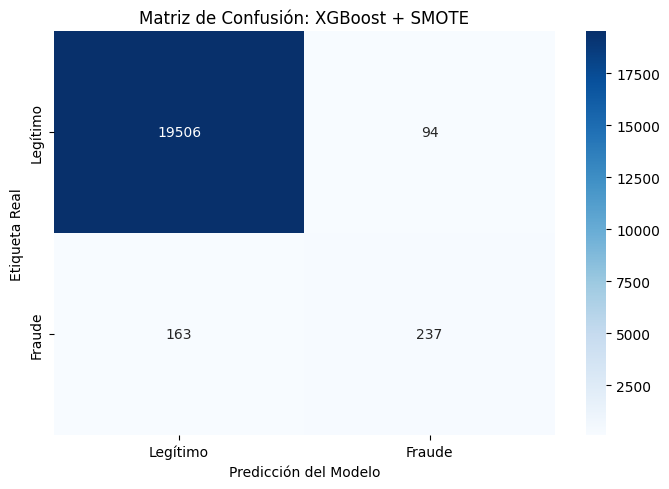

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ¡Importante! Usamos el Pipeline de imblearn, no el de sklearn normal
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# implemetnacion de features de riesgo
df['alerta_viaje'] = (df['pais_emision'] != df['pais_pago']).astype(int)
df['riesgo_tecnologico'] = ((df['dispositivo_nuevo'] == 1) & (df['uso_vpn_proxy'] == 1)).astype(int)
df['gasto_extremo'] = (df['ratio_monto_promedio'] > 4.0).astype(int)
# pasamos fecha a fin de semana
df['fecha'] = pd.to_datetime(df['fecha'])
df['es_fin_de_semana'] = df['fecha'].dt.dayofweek.isin([5, 6]).astype(int)


# 2. Separar características (X) y variable objetivo (y)
cols_to_drop = ['es_fraude', 'id_transaccion', 'id_usuario', 'fecha']
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df['es_fraude']

# 3. Identificar tipos de columnas para el preprocesamiento
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# 4. Crear el preprocesador (Escalado para números, One-Hot para categorías)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        # sparse_output=False ayuda a evitar problemas de compatibilidad con XGBoost
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# 5. Construir el Pipeline Híbrido (Preprocesamiento + SMOTE + XGBoost)
pipeline_xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),           
    ('smote', SMOTE(random_state=42)),        
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
        # NOTA: No usamos scale_pos_weight porque SMOTE ya balancea las clases
    ))
])

# 6. Dividir los datos (Test del 20% manteniendo la proporción real de fraudes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 7. Entrenar el modelo
print("Entrenando XGBoost con SMOTE (esto puede tardar un momento)...")
pipeline_xgb_smote.fit(X_train, y_train)

# 8. Predecir sobre el conjunto de prueba
print("Evaluando el modelo...")
y_pred = pipeline_xgb_smote.predict(X_test)

# 9. Mostrar resultados numéricos
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))

# 10. Visualizar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legítimo', 'Fraude'], 
            yticklabels=['Legítimo', 'Fraude'])
plt.title('Matriz de Confusión: XGBoost + SMOTE')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

In [8]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

#el preprocesado es el mismo que antes, no lo tocamos.

modelo_alto_recall = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        # Mentimos con el peso (el real era 49, le ponemos 100)
        scale_pos_weight=6,       
        max_delta_step=3,           
        learning_rate=0.05,
        max_depth=4,
        eval_metric='logloss',     
        random_state=42,
        n_jobs=-1
    ))
])

modelo_alto_recall.fit(X_train, y_train)

# Evaluamos
y_pred_agresivo = modelo_alto_recall.predict(X_test)
# print de reporte de clasificación
print(classification_report(y_test, y_pred_agresivo))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     19600
           1       0.49      0.90      0.64       400

    accuracy                           0.98     20000
   macro avg       0.74      0.94      0.81     20000
weighted avg       0.99      0.98      0.98     20000



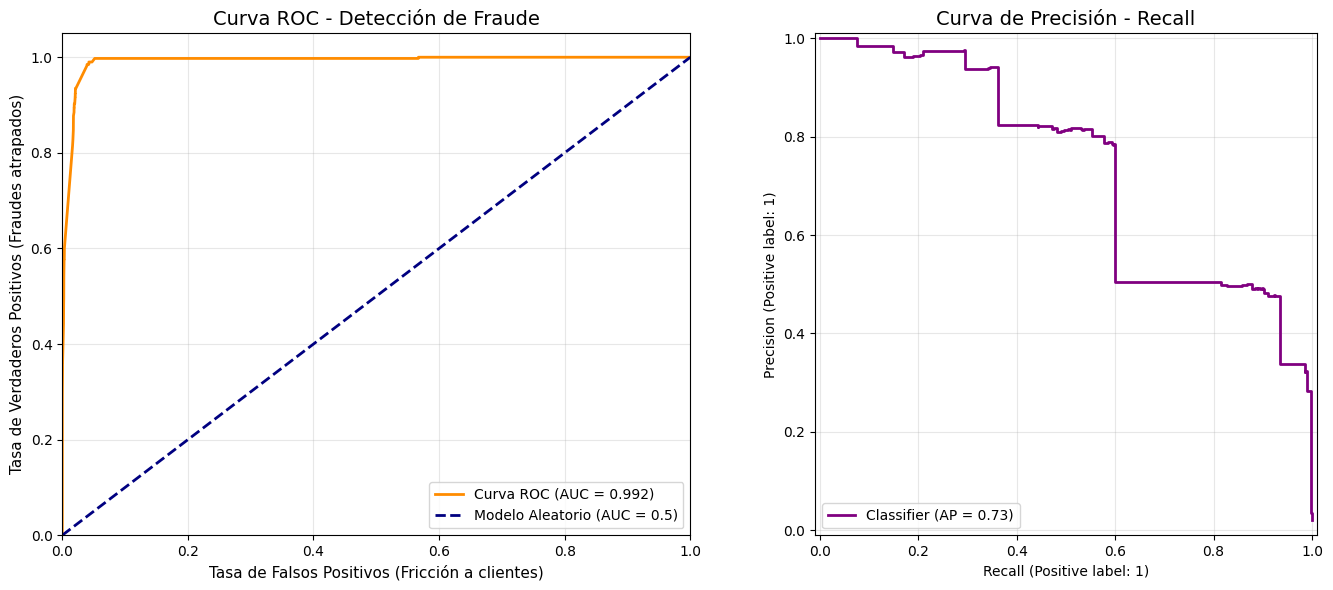


🏆 NOTA FINAL DEL MODELO (ROC AUC Score): 99.16/100


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, PrecisionRecallDisplay

# 1. Obtener las probabilidades de fraude (clase 1)
y_pred_proba = modelo_alto_recall.predict_proba(X_test)[:, 1]

# 2. Calcular los ratios para la curva ROC
fpr, tpr, umbrales_roc = roc_curve(y_test, y_pred_proba)

# 3. Calcular el AUC (Área Bajo la Curva)
auc_score = auc(fpr, tpr)

# --- CREAR LA GRÁFICA ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Curva ROC
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Aleatorio (AUC = 0.5)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos (Fricción a clientes)', fontsize=11)
ax1.set_ylabel('Tasa de Verdaderos Positivos (Fraudes atrapados)', fontsize=11)
ax1.set_title('Curva ROC - Detección de Fraude', fontsize=14)
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Gráfico 2: Curva de Precisión-Recall (Ideal para datos desbalanceados)
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=ax2, color='purple', lw=2)
ax2.set_title('Curva de Precisión - Recall', fontsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir la nota final
print(f"\n🏆 NOTA FINAL DEL MODELO (ROC AUC Score): {auc_score * 100:.2f}/100")

/tmp/ipykernel_8084/770736829.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=top_10_variables, palette='magma')


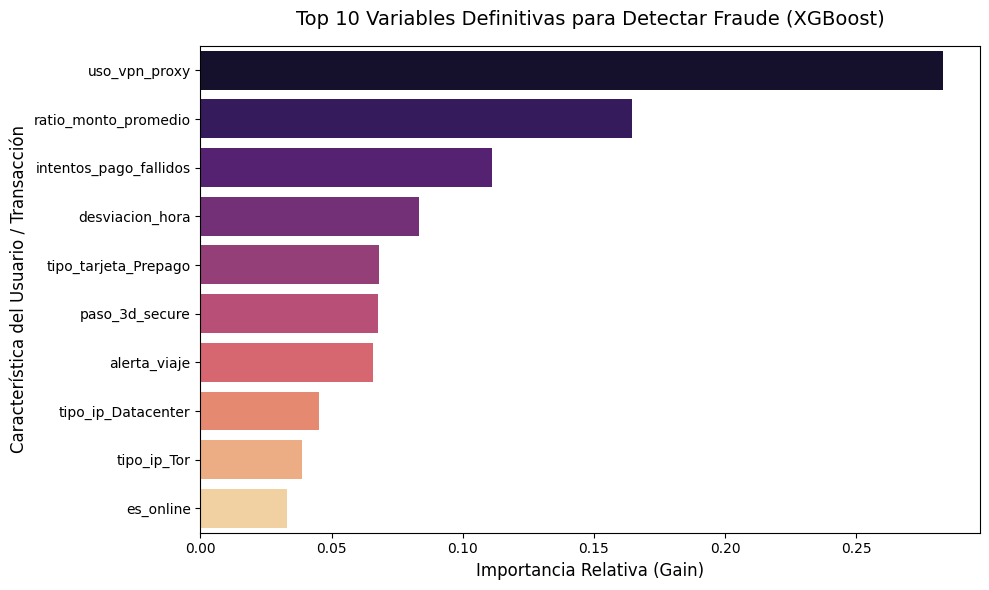

In [10]:
# TOP 10 VARIABLES DEFINITIVAS PARA DETECTAR FRAUDE

clasificador = modelo_alto_recall.named_steps['classifier']
preprocesador = modelo_alto_recall.named_steps['preprocessor']

encoder_categorico = preprocesador.named_transformers_['cat']
nombres_categoricos = encoder_categorico.get_feature_names_out(categorical_cols).tolist()

todos_los_nombres = numeric_cols + nombres_categoricos

importancias = clasificador.feature_importances_

df_importancias = pd.DataFrame({
    'Variable': todos_los_nombres,
    'Importancia': importancias
})

top_10_variables = df_importancias.sort_values(by='Importancia', ascending=False).head(10)

# Graficamos los resultados
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=top_10_variables, palette='magma')

plt.title('Top 10 Variables Definitivas para Detectar Fraude (XGBoost)', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa (Gain)', fontsize=12)
plt.ylabel('Característica del Usuario / Transacción', fontsize=12)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [12]:
import joblib

# Guardamos el pipeline completo
joblib.dump(modelo_alto_recall, '../models/modelo_alto_recall_dani.pkl')
print("Modelo guardado correctamente.")

Modelo guardado correctamente.
